# Aggregate MCMC vs SBI Comparison (Publication Quality)

Multi-panel figures comparing MCMC FTJ vs SBI FTJ across experiments.

**Figures generated:**
- Figure 8: Baseline experiments (in-distribution)
- Figure 10: Model misspecification experiments  
- Figure 11: Out-of-distribution experiments (R-M scatter, richness contamination)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle
import json
import sys
from pathlib import Path
import os

# Configure paths
ROOT = Path("..")
sys.path.insert(0, str(ROOT))
plt.style.use(os.path.join(ROOT, "plot", "mplstyle.txt"))

NUM_SIMS = 10000
NUM_OBS = 376

# =============================================================================
# COLOR SCHEME (colorblind-friendly)
# =============================================================================
COLORS = {
    "obs": "black",           # Observation distribution - high contrast
    "mcmc": "#0077BB",        # MCMC - blue (tol bright)
    "sbi": "#EE7733",         # SBI - orange (tol bright)
    "truth": "#CC3311",       # Truth marker - red
}

# =============================================================================
# EXPERIMENT CONFIGURATIONS - Matching Paper Exactly
# =============================================================================

# Figure 8: In-distribution experiments (4 rows)
# Sec 4.1 Baseline, 4.2 High M-c scatter, 4.3 High noise, 4.4 High R-M scatter
EXPERIMENTS_FIG8 = [
    ("sim_z1", "infer_z1", "obs_z1_lambda5", "Baseline"),
    ("sim_z1_high_mc_scatter", "infer_z1_high_mc_scatter", "obs_z1_lambda5_high_mc_scatter", "High M-c Scatter"),
    ("sim_z1_high_noise", "infer_z1", "obs_z1_lambda5_high_noise", "High Noise"),
    ("sim_z1_high_rm_scatter", "infer_z1_high_rm_scatter", "obs_z1_lambda5_high_rm_scatter", r"High $\lambda$-M Scatter"),
]

# Figure 10: Out-of-distribution - M-c relation & noise mismatch (4 rows)
# Rows 1-2: Wrong M-c relation (Prada, Ludlow)
# Rows 3-4: Noise mismatch (obs higher/lower noise than sims)
EXPERIMENTS_FIG10 = [
    ("sim_z1", "infer_z1", "obs_z1_lambda5_prada", "Prada M-c"),
    ("sim_z1", "infer_z1", "obs_z1_lambda5_ludlow", "Ludlow M-c"),
    ("sim_z1", "infer_z1", "obs_z1_lambda5_high_noise", "Obs higher noise than sims"),
    ("sim_z1_high_noise", "infer_z1", "obs_z1_lambda5", "Obs lower noise than sims"),
]

# Figure 11: Out-of-distribution - R-M scatter mismatch (2 rows)
# Sec 4.6.4 Lower λ-M scatter, 4.6.5 Higher λ-M scatter
EXPERIMENTS_FIG11 = [
    ("sim_z1", "infer_z1", "obs_z1_lambda5_high_rm_scatter", r"Obs: Higher $\lambda$-M Scatter"),
    ("sim_z1_high_rm_scatter", "infer_z1_high_rm_scatter", "obs_z1_lambda5", r"Obs: Lower $\lambda$-M Scatter"),
]

print("Experiment sets configured: Fig 8 (4), Fig 10 (4), Fig 11 (2)")

Experiment sets configured: Fig 8 (4), Fig 10 (4), Fig 11 (2)


In [2]:
def load_experiment_data(sim_id, infer_id, obs_id):
    """Load chains and metadata for an experiment."""
    infer_path = ROOT / f"outputs/inference/{sim_id}.{infer_id}.{obs_id}.{NUM_SIMS}.{NUM_OBS}"
    obs_path = ROOT / f"outputs/observations/{obs_id}.{NUM_OBS}"

    # Load MCMC JTF chain (join-then-fit: median profile then MCMC)
    with open(infer_path / "mcmc_jtf_sampler.pickle", "rb") as f:
        mcmc_jtf_sampler = pickle.load(f)
    mcmc_jtf = mcmc_jtf_sampler.flatchain[:, :2]  # Drop log_f
    
    # Load MCMC FTJ chain (fit-then-join: joint likelihood over all observations)
    with open(infer_path / "mcmc_ftj_samplers.pickle", "rb") as f:
        mcmc_ftj_sampler = pickle.load(f)
    mcmc_ftj = mcmc_ftj_sampler.flatchain[:, :2]  # Drop log_f

    # Load SBI chains
    with open(infer_path / "sbi_chains.pickle", "rb") as f:
        sbi_chains = pickle.load(f)
    sbi_ftj = sbi_chains[1]

    # Process SBI FTJ - Gaussian approximation from percentile spread
    n_levels = 7
    med_idx = 3
    idx_16, idx_84 = 1, 5

    mass_percentiles = sbi_ftj[:, :n_levels]
    conc_percentiles = sbi_ftj[:, n_levels:2*n_levels]
    correlations = sbi_ftj[:, -1]

    mu_mass = np.median(mass_percentiles[:, med_idx])
    mu_conc = np.median(conc_percentiles[:, med_idx])
    sigma_mass = (np.median(mass_percentiles[:, idx_84]) - np.median(mass_percentiles[:, idx_16])) / 2.0
    sigma_conc = (np.median(conc_percentiles[:, idx_84]) - np.median(conc_percentiles[:, idx_16])) / 2.0
    rho = np.median(np.clip(correlations, -0.99, 0.99))

    cov = np.array([
        [sigma_mass**2, rho * sigma_mass * sigma_conc],
        [rho * sigma_mass * sigma_conc, sigma_conc**2]
    ])
    rng = np.random.default_rng(42)
    sbi_ftj_mc = rng.multivariate_normal(mean=[mu_mass, mu_conc], cov=cov, size=10000)

    # Load truth
    true_median = np.load(infer_path / "true_param_median.npy")

    # Load observed M-c pairs for distribution
    obs_mc_pairs = np.load(obs_path / "drawn_mc_pairs.npy")

    return {
        "mcmc_jtf": mcmc_jtf,
        "mcmc_ftj": mcmc_ftj,
        "sbi_ftj": sbi_ftj_mc,
        "true_median": true_median,
        "obs_mc_pairs": obs_mc_pairs,
    }


def load_all_experiments(experiment_list):
    """Load data for a list of experiments."""
    data = {}
    for sim_id, infer_id, obs_id, label in experiment_list:
        try:
            data[label] = load_experiment_data(sim_id, infer_id, obs_id)
            print(f"  Loaded: {label}")
        except FileNotFoundError as e:
            print(f"  MISSING: {label} ({sim_id}.{infer_id}.{obs_id})")
    return data


# Load all experiment sets
print("Loading Figure 8 experiments (4 rows)...")
data_fig8 = load_all_experiments(EXPERIMENTS_FIG8)

print("\nLoading Figure 10 experiments (4 rows)...")
data_fig10 = load_all_experiments(EXPERIMENTS_FIG10)

print("\nLoading Figure 11 experiments (2 rows)...")
data_fig11 = load_all_experiments(EXPERIMENTS_FIG11)

print(f"\nLoaded: Fig8={len(data_fig8)}/4, Fig10={len(data_fig10)}/4, Fig11={len(data_fig11)}/2")

Loading Figure 8 experiments (4 rows)...
  Loaded: Baseline
  Loaded: High M-c Scatter
  Loaded: High Noise
  Loaded: High $\lambda$-M Scatter

Loading Figure 10 experiments (4 rows)...
  Loaded: Prada M-c
  Loaded: Ludlow M-c
  Loaded: Obs higher noise than sims
  Loaded: Obs lower noise than sims

Loading Figure 11 experiments (2 rows)...
  Loaded: Obs: Higher $\lambda$-M Scatter
  Loaded: Obs: Lower $\lambda$-M Scatter

Loaded: Fig8=4/4, Fig10=4/4, Fig11=2/2


In [3]:
# =============================================================================
# PLOTTING FUNCTIONS (Publication Quality - Row Format)
# =============================================================================

def plot_kde_contours(ax, samples, color, levels=[0.95, 0.997], 
                      fill=True, ls="-", lw=1.5, alpha_fill=0.2):
    """Plot 2D KDE contours at specified credible levels."""
    x, y = samples[:, 0], samples[:, 1]
    
    xmin, xmax = x.min() - 0.2, x.max() + 0.2
    ymin, ymax = y.min() - 0.5, y.max() + 0.5
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    try:
        kernel = stats.gaussian_kde(samples.T)
        f = np.reshape(kernel(positions).T, xx.shape)
    except np.linalg.LinAlgError:
        return
    
    sorted_f = np.sort(f.ravel())[::-1]
    cumsum = np.cumsum(sorted_f)
    cumsum /= cumsum[-1]
    contour_levels = [sorted_f[np.searchsorted(cumsum, level)] for level in levels]
    contour_levels = sorted(contour_levels)
    
    if fill:
        ax.contourf(xx, yy, f, levels=[contour_levels[0], contour_levels[-1], f.max()],
                    colors=[color], alpha=[alpha_fill, alpha_fill * 1.5])
    ax.contour(xx, yy, f, levels=contour_levels, colors=[color], linewidths=lw, linestyles=ls)


def create_row_figure(data_dict, output_name, figsize_per_row=(12, 2.8)):
    """
    Create multi-row figure with 3 columns per experiment:
    - Col 1: 2D posterior contours
    - Col 2: Mass marginal
    - Col 3: Concentration marginal
    """
    n_experiments = len(data_dict)
    fig, axes = plt.subplots(n_experiments, 3, figsize=(figsize_per_row[0], figsize_per_row[1] * n_experiments))
    
    if n_experiments == 1:
        axes = axes.reshape(1, -1)
    
    panel_labels = [f"({chr(97+i)})" for i in range(n_experiments)]
    
    for idx, (label, exp_data) in enumerate(data_dict.items()):
        true = exp_data["true_median"]
        mcmc = exp_data["mcmc_ftj"]  # Use FTJ joint likelihood chain
        sbi = exp_data["sbi_ftj"]
        obs = exp_data["obs_mc_pairs"]
        
        is_last = (idx == n_experiments - 1)
        
        # ---------------------------------------------------------------------
        # Column 1: 2D Posterior
        # ---------------------------------------------------------------------
        ax = axes[idx, 0]
        
        # Observations (black, dashed, unfilled)
        plot_kde_contours(ax, obs, COLORS["obs"], fill=False, ls="--", lw=2)
        # MCMC (blue, filled)
        plot_kde_contours(ax, mcmc, COLORS["mcmc"], fill=True, alpha_fill=0.25)
        # SBI (orange, filled)
        plot_kde_contours(ax, sbi, COLORS["sbi"], fill=True, alpha_fill=0.25)
        # Truth marker
        ax.scatter(true[0], true[1], marker="*", s=180, c=COLORS["truth"], 
                   edgecolors="k", linewidths=0.5, zorder=10)
        
        # Panel label and experiment name
        ax.text(0.03, 0.97, f"{panel_labels[idx]} {label}", transform=ax.transAxes, 
                fontsize=11, fontweight="bold", va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none"))
        
        ax.set_ylabel("Concentration", fontsize=11)
        if is_last:
            ax.set_xlabel(r"$\log_{10}(M_{200m}/M_\odot)$", fontsize=11)
        if idx == 0:
            ax.set_title("2D Posterior", fontsize=12, fontweight="bold")
        
        # ---------------------------------------------------------------------
        # Column 2: Mass Marginal
        # ---------------------------------------------------------------------
        ax = axes[idx, 1]
        
        bins_mass = np.linspace(min(obs[:,0].min(), mcmc[:,0].min(), sbi[:,0].min()) - 0.1,
                                max(obs[:,0].max(), mcmc[:,0].max(), sbi[:,0].max()) + 0.1, 35)
        
        ax.hist(obs[:, 0], bins=bins_mass, density=True, alpha=0.4, color=COLORS["obs"], 
                label="Obs", histtype="stepfilled", edgecolor=COLORS["obs"], linewidth=1.5)
        ax.hist(mcmc[:, 0], bins=bins_mass, density=True, alpha=0.5, color=COLORS["mcmc"], 
                label="MCMC", histtype="stepfilled")
        ax.hist(sbi[:, 0], bins=bins_mass, density=True, alpha=0.5, color=COLORS["sbi"], 
                label="SBI", histtype="stepfilled")
        ax.axvline(true[0], color=COLORS["truth"], ls="--", lw=2.5)
        
        ax.set_ylabel("Density", fontsize=11)
        if is_last:
            ax.set_xlabel(r"$\log_{10}(M_{200m}/M_\odot)$", fontsize=11)
        if idx == 0:
            ax.set_title("Mass Marginal", fontsize=12, fontweight="bold")
            ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
        
        # ---------------------------------------------------------------------
        # Column 3: Concentration Marginal
        # ---------------------------------------------------------------------
        ax = axes[idx, 2]
        
        bins_conc = np.linspace(min(obs[:,1].min(), mcmc[:,1].min(), sbi[:,1].min()) - 0.2,
                                max(obs[:,1].max(), mcmc[:,1].max(), sbi[:,1].max()) + 0.2, 35)
        
        ax.hist(obs[:, 1], bins=bins_conc, density=True, alpha=0.4, color=COLORS["obs"],
                histtype="stepfilled", edgecolor=COLORS["obs"], linewidth=1.5)
        ax.hist(mcmc[:, 1], bins=bins_conc, density=True, alpha=0.5, color=COLORS["mcmc"],
                histtype="stepfilled")
        ax.hist(sbi[:, 1], bins=bins_conc, density=True, alpha=0.5, color=COLORS["sbi"],
                histtype="stepfilled")
        ax.axvline(true[1], color=COLORS["truth"], ls="--", lw=2.5)
        
        ax.set_ylabel("Density", fontsize=11)
        if is_last:
            ax.set_xlabel("Concentration", fontsize=11)
        if idx == 0:
            ax.set_title("Concentration Marginal", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    fig.savefig(ROOT / f"outputs/{output_name}.pdf", bbox_inches="tight", dpi=300)
    fig.savefig(ROOT / f"outputs/{output_name}.png", bbox_inches="tight", dpi=150)
    print(f"Saved: outputs/{output_name}.pdf")
    
    return fig


print("Row-format plotting functions defined.")

Row-format plotting functions defined.


Saved: outputs/figure8_baseline_comparison.pdf


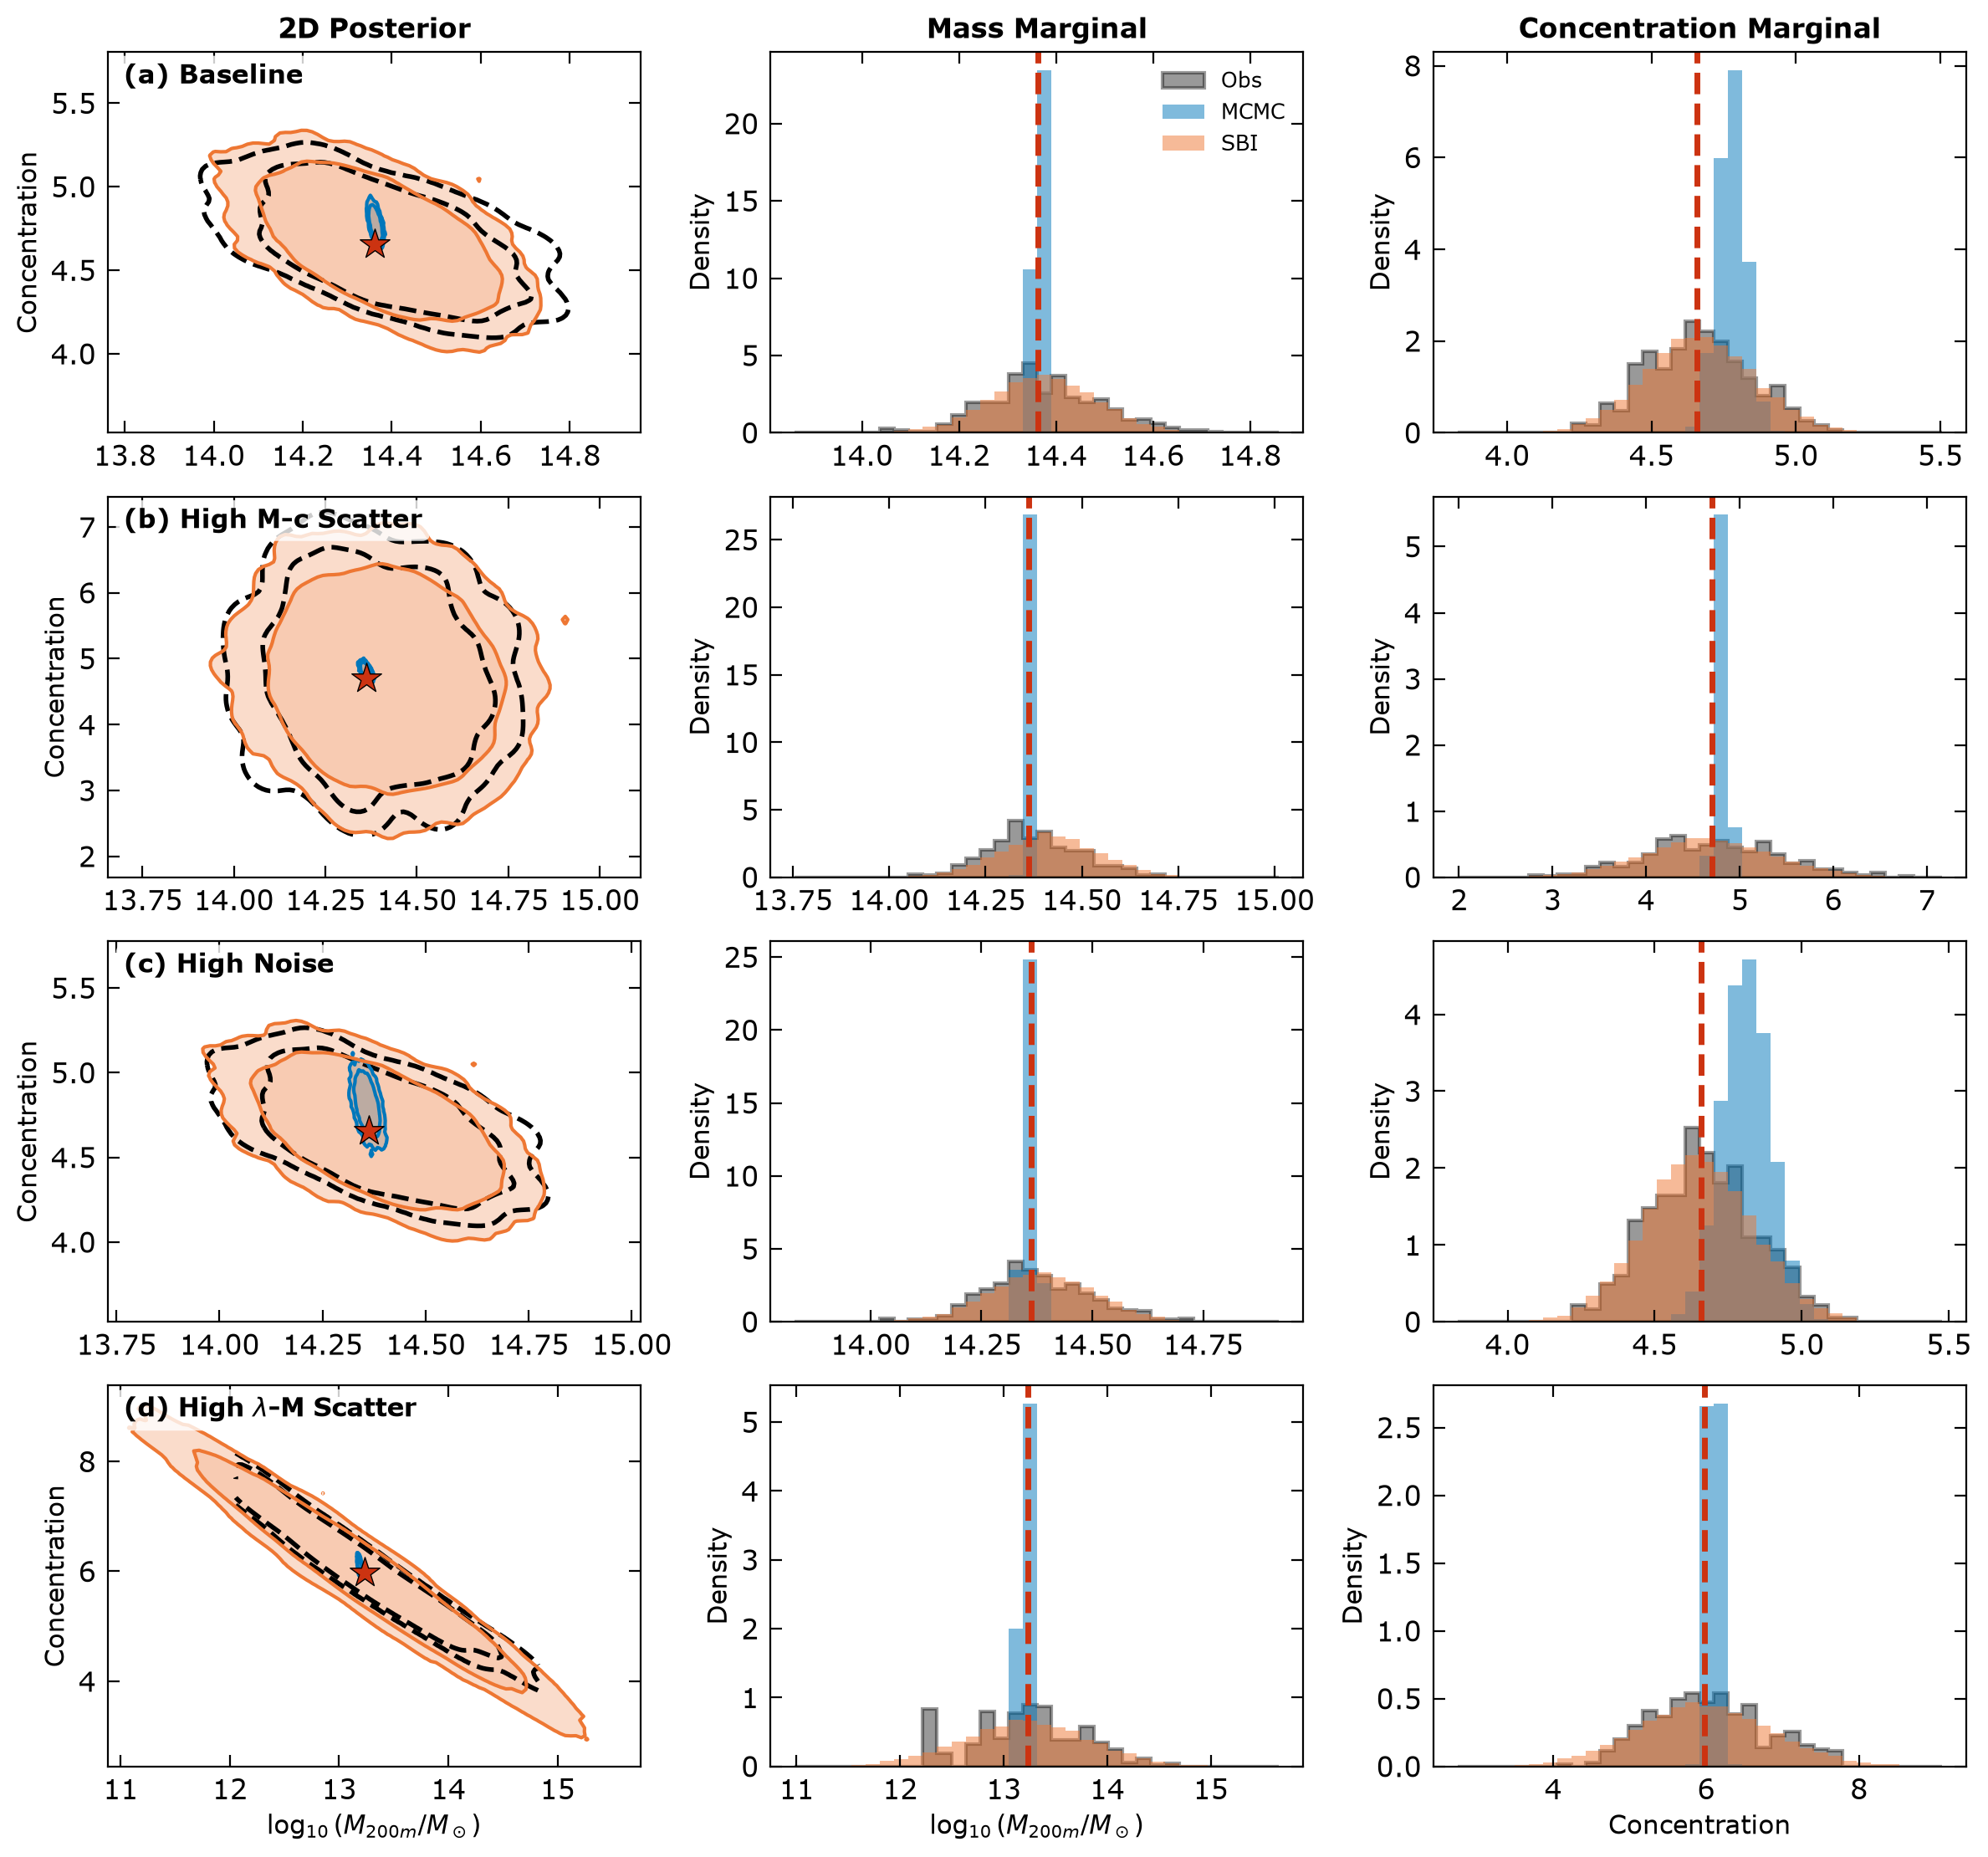

In [4]:
# =============================================================================
# FIGURE 8: In-Distribution Experiments (4 rows)
# =============================================================================

if len(data_fig8) > 0:
    fig8 = create_row_figure(data_fig8, "figure8_baseline_comparison")
    plt.show()
else:
    print("No data loaded for Figure 8")

Saved: outputs/figure10_mc_mismatch.pdf


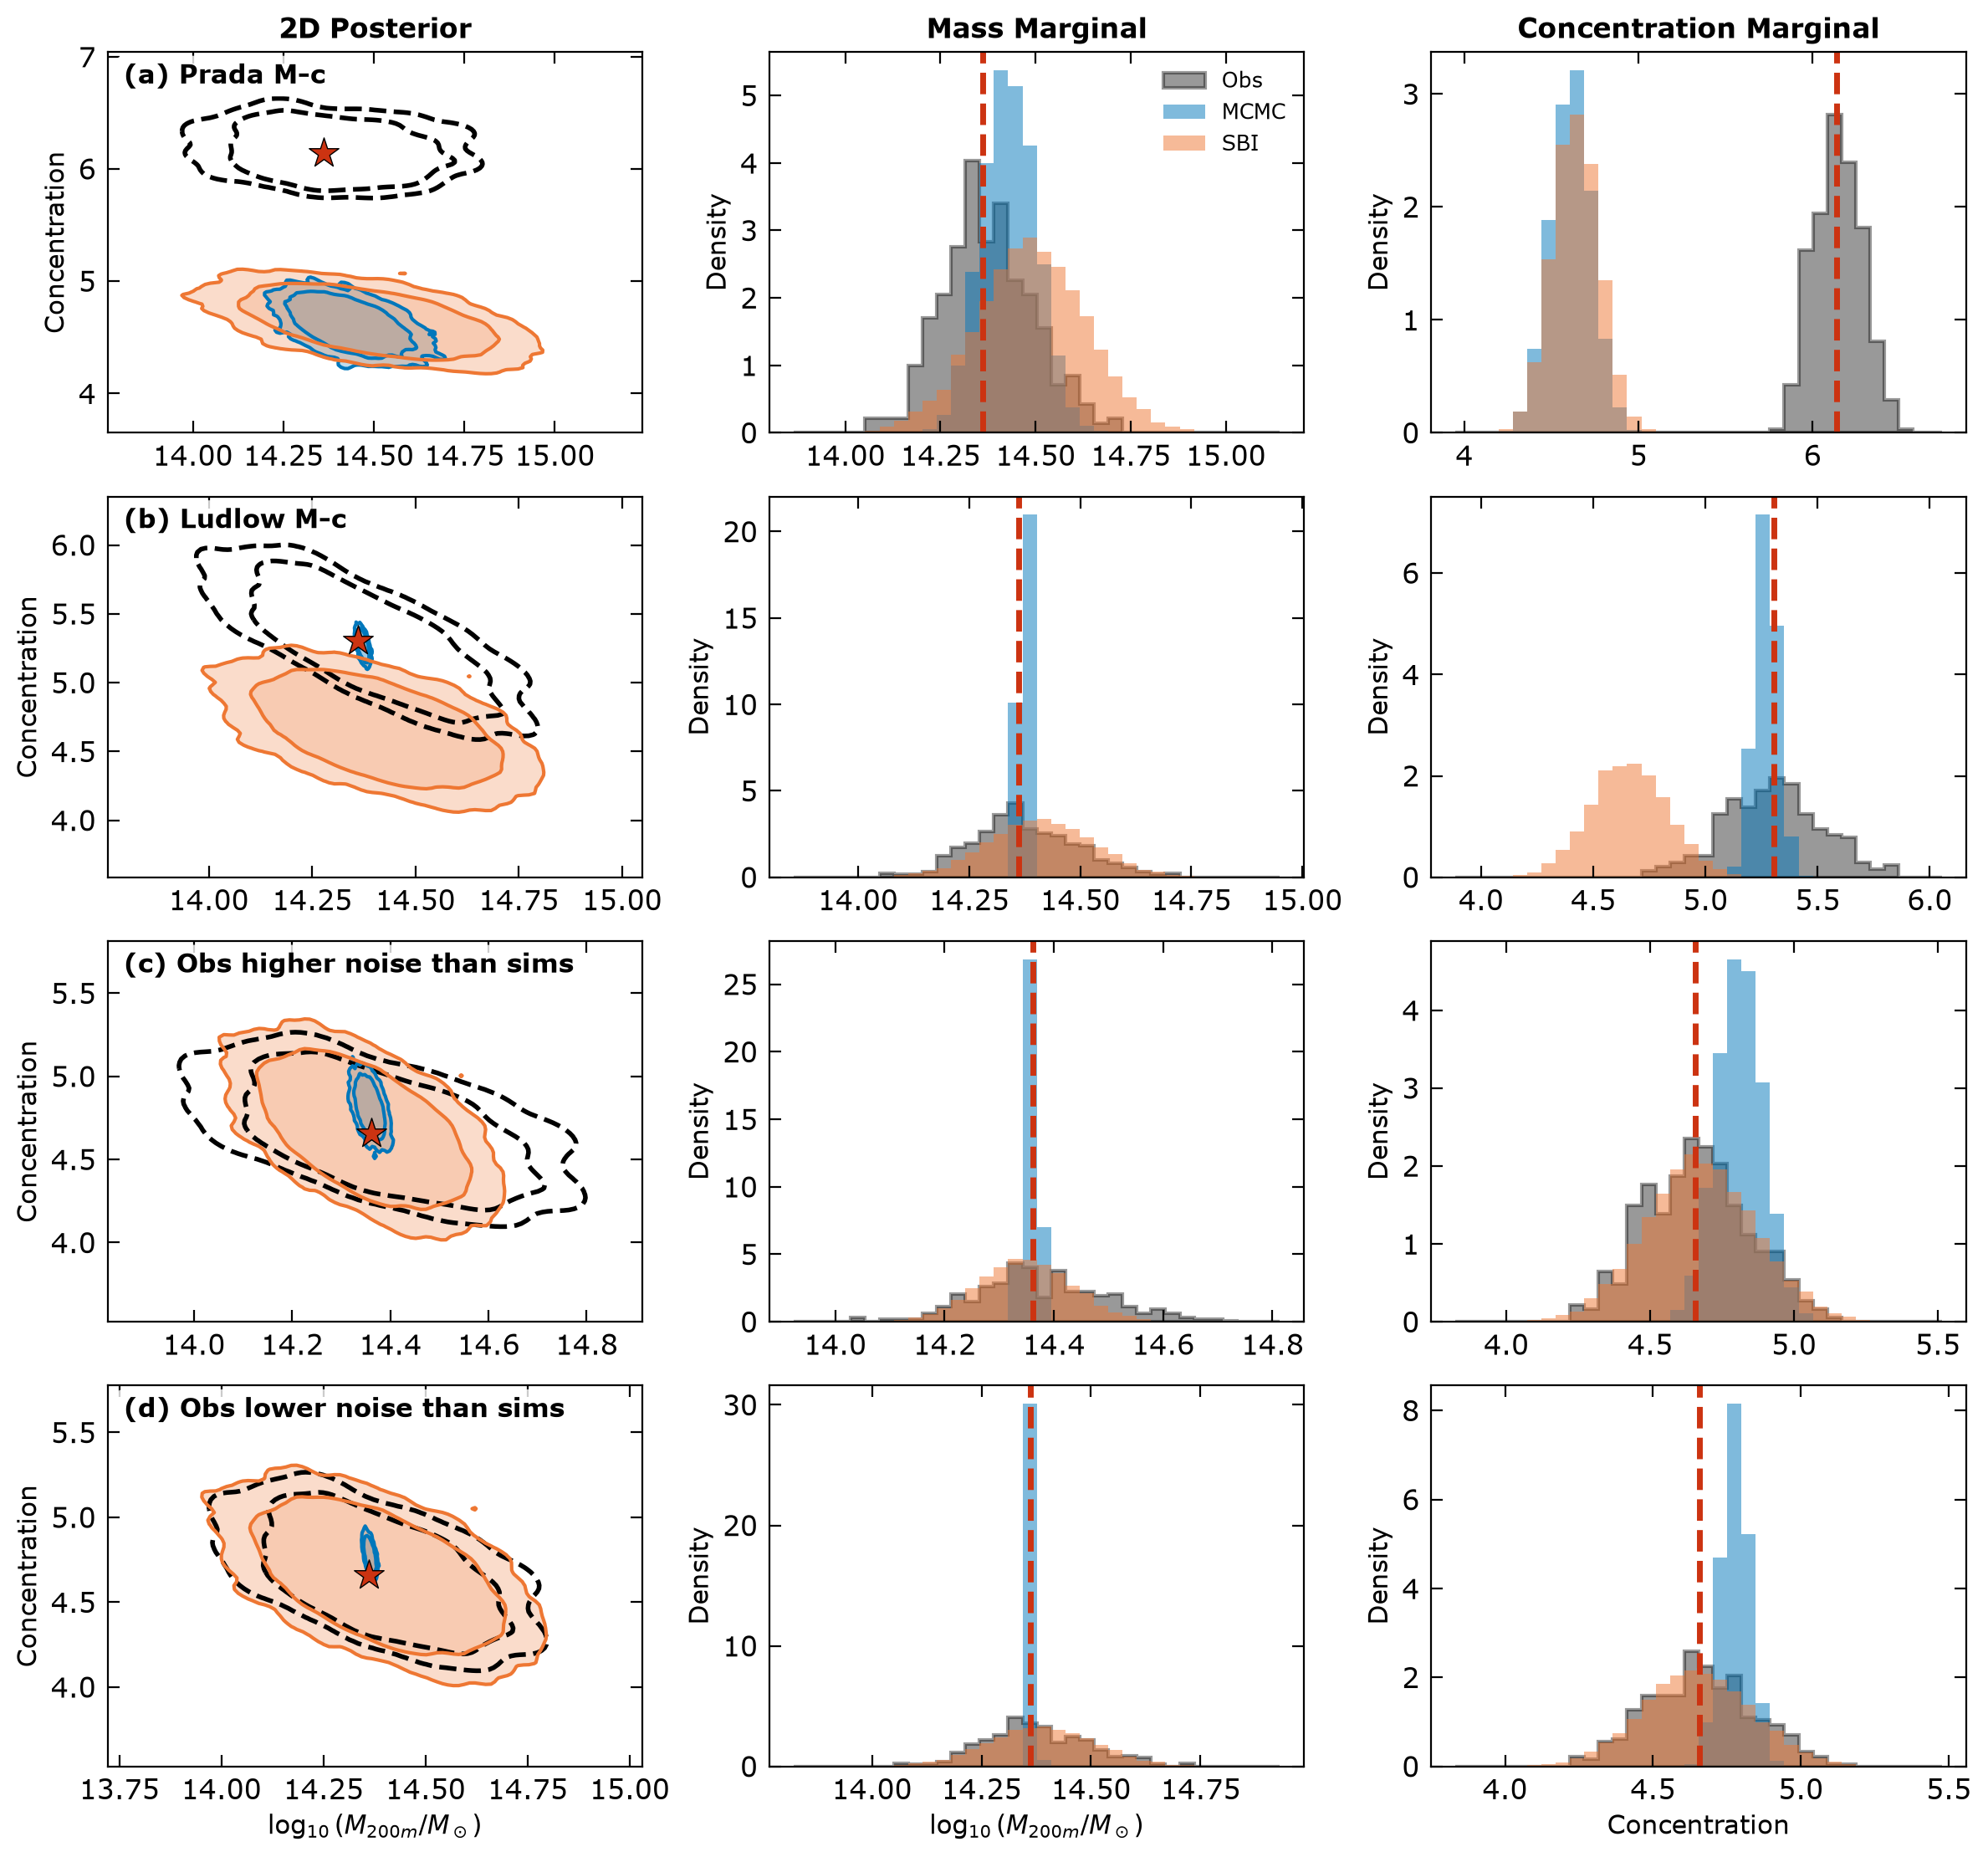

In [5]:
# =============================================================================
# FIGURE 10: Model Misspecification - M-c Relation (4 rows)
# =============================================================================

if len(data_fig10) > 0:
    fig10 = create_row_figure(data_fig10, "figure10_mc_mismatch")
    plt.show()
else:
    print("No data loaded for Figure 10")

Saved: outputs/figure11_ood_comparison.pdf


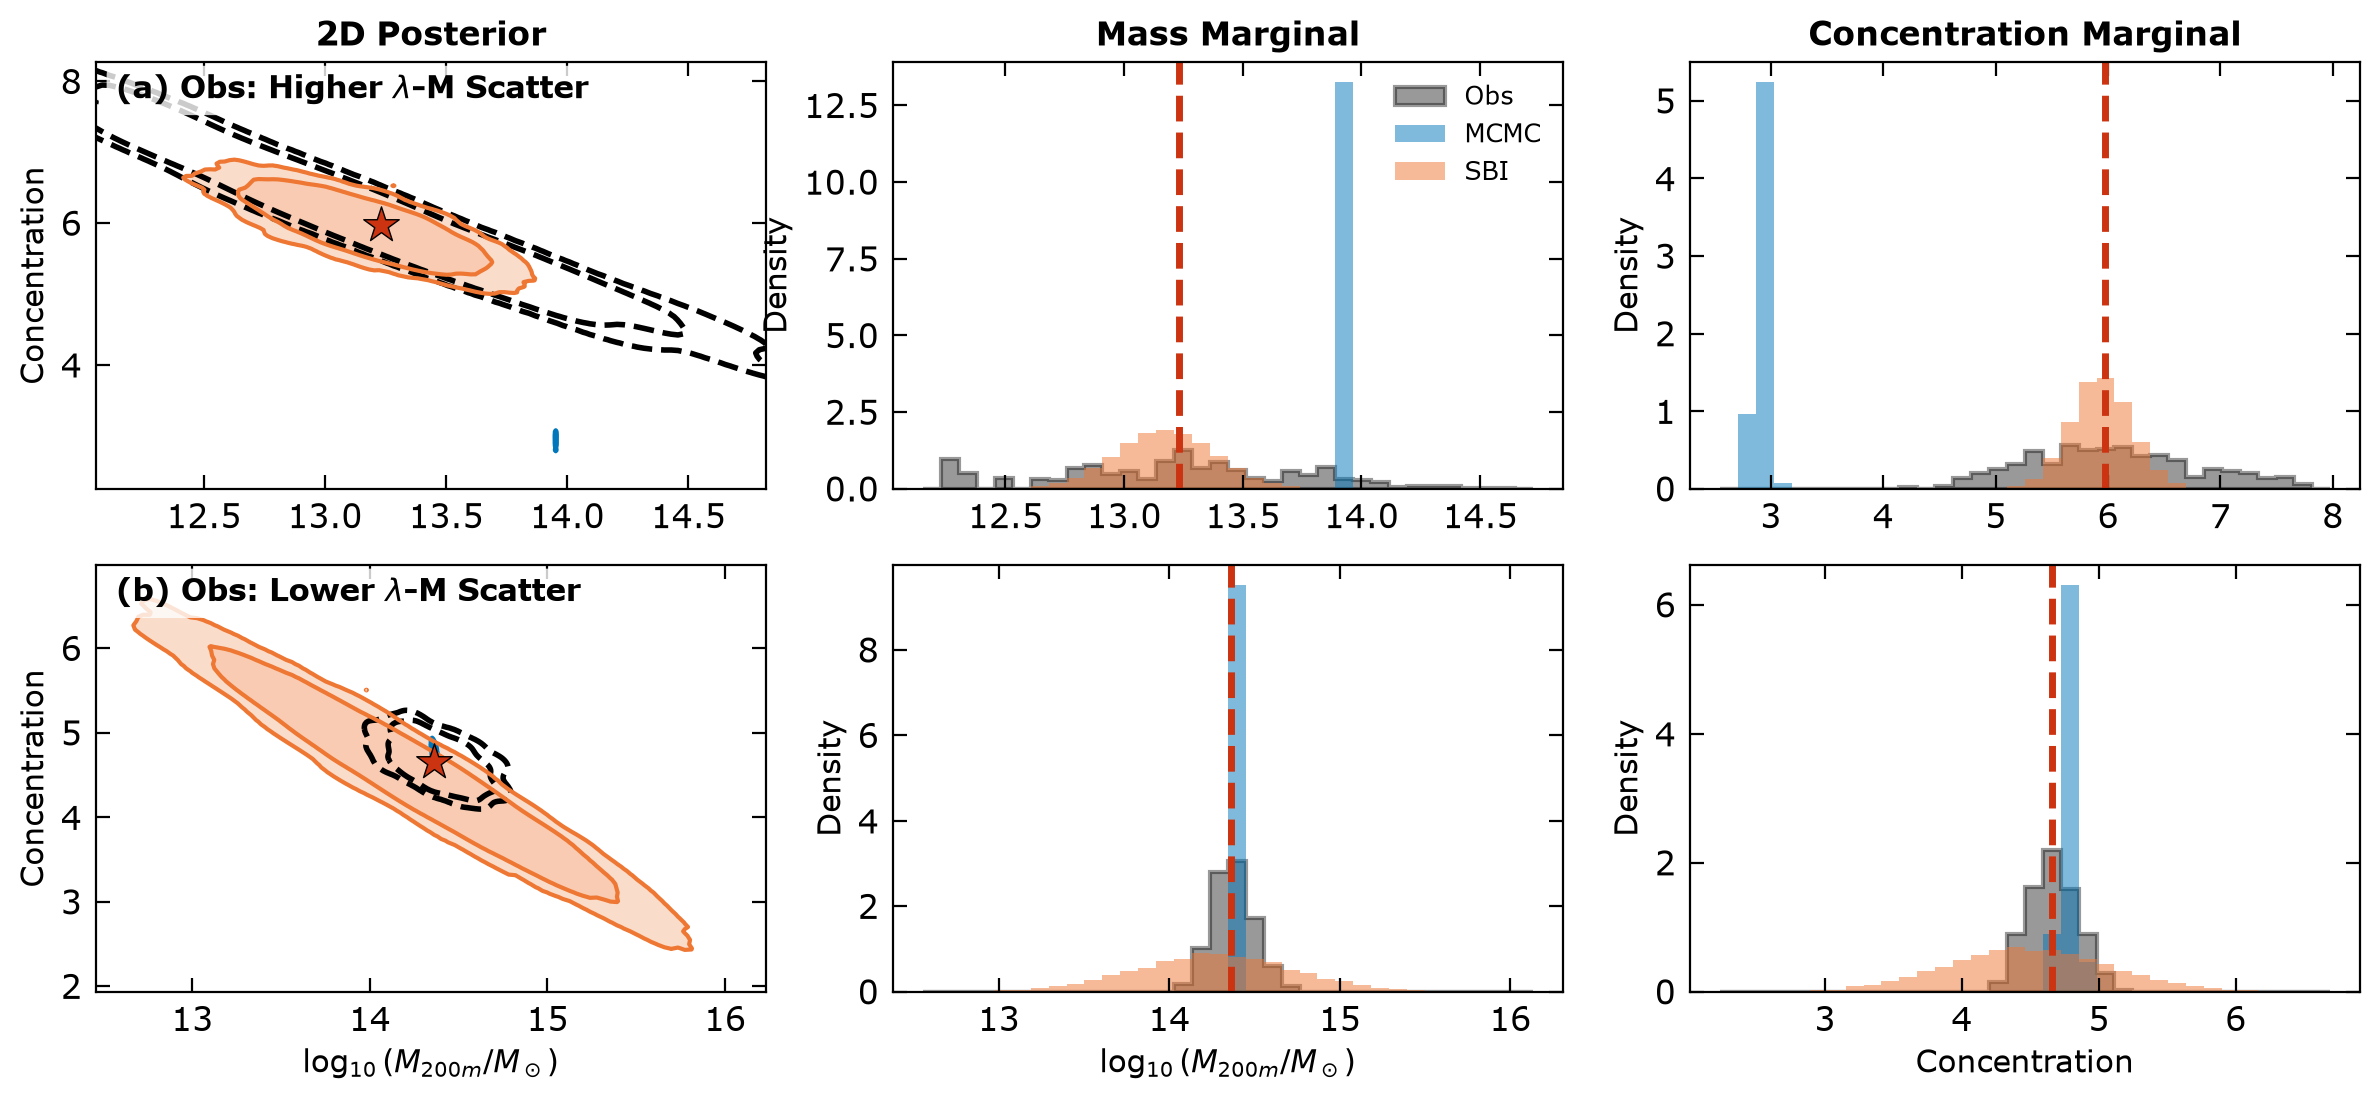

In [6]:
# =============================================================================
# FIGURE 11: Out-of-Distribution - R-M Scatter & Contamination (3 rows)
# =============================================================================

if len(data_fig11) > 0:
    fig11 = create_row_figure(data_fig11, "figure11_ood_comparison")
    plt.show()
else:
    print("No data loaded for Figure 11")

In [7]:
# =============================================================================
# SUMMARY STATISTICS (with observation distribution as truth uncertainty)
# =============================================================================

def print_summary(data_dict, title):
    """Print summary statistics for experiments including observation spread."""
    print(f"\n{title}")
    print("=" * 130)
    print(f"{'Experiment':<30} | {'Obs M (truth)':>18} | {'MCMC FTJ M':>14} | {'SBI FTJ M':>14} | {'Obs c (truth)':>16} | {'MCMC FTJ c':>11} | {'SBI FTJ c':>11}")
    print("-" * 130)
    
    for label, exp_data in data_dict.items():
        true = exp_data["true_median"]
        mcmc = exp_data["mcmc_ftj"]  # Use FTJ joint likelihood chain
        sbi = exp_data["sbi_ftj"]
        obs = exp_data["obs_mc_pairs"]
        
        # Observation distribution stats (this IS the truth distribution we're trying to infer)
        obs_m_med = np.median(obs[:, 0])
        obs_m_std = np.std(obs[:, 0])
        obs_c_med = np.median(obs[:, 1])
        obs_c_std = np.std(obs[:, 1])
        
        print(f"{label:<30} | {obs_m_med:>6.2f} +/- {obs_m_std:.2f} | "
              f"{np.median(mcmc[:,0]):>5.2f} +/- {np.std(mcmc[:,0]):.2f} | "
              f"{np.median(sbi[:,0]):>5.2f} +/- {np.std(sbi[:,0]):.2f} | "
              f"{obs_c_med:>5.2f} +/- {obs_c_std:.2f} | "
              f"{np.median(mcmc[:,1]):>4.2f} +/- {np.std(mcmc[:,1]):.2f} | "
              f"{np.median(sbi[:,1]):>4.2f} +/- {np.std(sbi[:,1]):.2f}")

if data_fig8:
    print_summary(data_fig8, "FIGURE 8: In-Distribution Experiments")
    
if data_fig10:
    print_summary(data_fig10, "FIGURE 10: M-c Relation Mismatch")
    
if data_fig11:
    print_summary(data_fig11, "FIGURE 11: Out-of-Distribution Experiments")

print("\n\nKey: 'Obs (truth)' shows the distribution of observed cluster parameters - this is what we're trying to recover.")
print("A good inference method should have similar spread to the observation distribution.")
print("\nNote: MCMC currently uses flat priors. Re-run experiments with --regenerate to use informed priors.")
print("\nAll figures saved to outputs/ directory.")


FIGURE 8: In-Distribution Experiments
Experiment                     |      Obs M (truth) |     MCMC FTJ M |      SBI FTJ M |    Obs c (truth) |  MCMC FTJ c |   SBI FTJ c
----------------------------------------------------------------------------------------------------------------------------------
Baseline                       |  14.36 +/- 0.12 | 14.36 +/- 0.01 | 14.37 +/- 0.11 |  4.66 +/- 0.18 | 4.78 +/- 0.05 | 4.66 +/- 0.19
High M-c Scatter               |  14.36 +/- 0.12 | 14.36 +/- 0.01 | 14.41 +/- 0.13 |  4.70 +/- 0.72 | 4.81 +/- 0.05 | 4.66 +/- 0.69
High Noise                     |  14.36 +/- 0.12 | 14.36 +/- 0.01 | 14.39 +/- 0.12 |  4.66 +/- 0.18 | 4.81 +/- 0.08 | 4.65 +/- 0.18
High $\lambda$-M Scatter       |  13.23 +/- 0.54 | 13.19 +/- 0.01 | 13.21 +/- 0.61 |  5.98 +/- 0.74 | 6.10 +/- 0.07 | 5.96 +/- 0.87

FIGURE 10: M-c Relation Mismatch
Experiment                     |      Obs M (truth) |     MCMC FTJ M |      SBI FTJ M |    Obs c (truth) |  MCMC FTJ c |   SBI FTJ c
--